# Análise Exploratória do Dataset Carros Usados

Discente: Guilherme da Silva Ferraz


In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway


# 1. Compreensão Inicial dos Dados

### Carregar o Dataset e Visualizar os Dados

In [36]:
carro = pd.read_csv('carros_usados.csv', encoding='latin1', sep=';')

**Exibição das 5 primeiras linhas do conjunto de dados**

In [37]:
carro.head()

,ï»¿data.set,total.cost,lot.sale.days,overage,mileage,vehicle.type,domestic.import,vehicle.age,vehicle.age.group,color.set,makex,state,make.model
0,TRAIN,4037,135,YES,67341,FAMILY.LARGE,Domestic,8,SEVEN+,SILVER,BUICK,CA,BUICK.CENTURY
1,TRAIN,6886,114,YES,72823,FAMILY.MEDIUM,Domestic,6,SIX,WHITE,DODGE,AZ,DODGE.NEON
2,TRAIN,3924,205,YES,96330,FAMILY.MEDIUM,Domestic,9,SEVEN+,WHITE,OLDSMOBILE,FL,OLDSMOBILE.CUTLASS SUPREME
3,TRAIN,4636,100,YES,58519,ECONOMY,Import,4,FOUR,GOLD,KIA,NV,KIA.SEPHIA
4,TRAIN,5080,129,YES,99057,FAMILY.MEDIUM,Domestic,4,FOUR,GREEN,OLDSMOBILE,NV,OLDSMOBILE.CUTLASS SUPREME


**Exibição das últimas 5 linhas do conjunto de dados**

In [38]:
carro.tail()

,ï»¿data.set,total.cost,lot.sale.days,overage,mileage,vehicle.type,domestic.import,vehicle.age,vehicle.age.group,color.set,makex,state,make.model
7490,TRAIN,4625,37,NO,67131,FAMILY.MEDIUM,Domestic,5,FIVE,RED,BUICK,TX,BUICK.SKYLARK
7491,TEST,4024,37,NO,77425,LUXURY,Domestic,9,SEVEN+,GOLD,OTHER,TX,LINCOLN.TOWN CAR
7492,TRAIN,4910,33,NO,61011,LUXURY,Import,5,FIVE,BLUE,NISSAN,TX,NISSAN.ALTIMA
7493,TEST,4669,3,NO,81518,LUXURY,Import,6,SIX,WHITE,NISSAN,VA,NISSAN.ALTIMA
7494,VALIDATE,6078,69,NO,76281,FAMILY.MEDIUM,Domestic,6,SIX,BLUE,FORD,NV,FORD.TAURUS


**Descrição das Variáveis** 

**data.set** - Dado de treino ou de test  
**total.cost** - Custo total do veículo  
**lot.sale.days** - Tempo de venda em dias  
**overage** - Venda após 90 dias  
**mileage** - Kilometragem  
**vehicle.type** - Tipo do veículo (economy, family.medium, family.large...)  
**domestic.import** - Fabricação, doméstico ou importado  
**vehicle.age** - Idade do veículo  
**vehicle.age.group** - Grupo de idade do veículo  
**color.set** - Cor  
**makex** - Marca  
**state** - Estado do Carro (região)  
**make.model** - Modelo


***Tamanho do conjunto de dados***

In [39]:
carro.shape

(7495, 13)

***Tipos de variáveis***

In [40]:
carro.dtypes

ï»¿data.set          object
total.cost            int64
lot.sale.days         int64
overage              object
mileage               int64
vehicle.type         object
domestic.import      object
vehicle.age           int64
vehicle.age.group    object
color.set            object
makex                object
state                object
make.model           object
dtype: object

***Nome das colunas***

In [41]:
carro.columns

Index(['ï»¿data.set', 'total.cost', 'lot.sale.days', 'overage', 'mileage',
       'vehicle.type', 'domestic.import', 'vehicle.age', 'vehicle.age.group',
       'color.set', 'makex', 'state', 'make.model'],
      dtype='object')

***Valores ausentes (missing values):***

In [42]:
carro.isnull().sum()

ï»¿data.set          0
total.cost           0
lot.sale.days        0
overage              0
mileage              0
vehicle.type         0
domestic.import      0
vehicle.age          0
vehicle.age.group    0
color.set            0
makex                0
state                0
make.model           0
dtype: int64

***Valores Únicos em uma Coluna***

In [43]:
carro['total.cost'].unique()

array([4037, 6886, 3924, ..., 6971, 3526, 3209], shape=(3129,))

***Quantidade de Valores Únicos por Coluna***

In [44]:
carro.nunique()

ï»¿data.set             3
total.cost           3129
lot.sale.days         287
overage                 2
mileage              7019
vehicle.type            5
domestic.import         2
vehicle.age            12
vehicle.age.group       5
color.set               8
makex                  20
state                   8
make.model             95
dtype: int64

## Estatísticas Descritivas

***1. Medidas de Tendência Central***

In [45]:
columns = ['lot.sale.days', 'total.cost', 'mileage', 'vehicle.age']
for column in columns:
    print(f"Resultados de {column}:")
    print(f"  Média: {carro[column].mean()}")
    print(f"  Mediana: {carro[column].median()}")
    print(f"  Moda: {carro[column].mode()[0]}")
    print()

Resultados de lot.sale.days:
  Média: 76.45430286857905
  Mediana: 73.0
  Moda: 1

Resultados de total.cost:
  Média: 4980.035490326884
  Mediana: 4919.0
  Moda: 4836

Resultados de mileage:
  Média: 77234.53342228151
  Mediana: 78534.0
  Moda: 78518

Resultados de vehicle.age:
  Média: 5.567311541027352
  Mediana: 5.0
  Moda: 5



***2. Medidas de Dispersão***

In [46]:
columns = ['lot.sale.days', 'total.cost', 'mileage', 'vehicle.age']
for column in columns:
    print(f"Resultados de {column}:")
    print(f"  Desvio Padrão: {carro[column].std().round(5)}")
    print(f"  Variância: {carro[column].var().round(5)}")
    print(f"  Amplitude: {(carro[column].max() - carro[column].min()).round(5)}")
    print()

Resultados de lot.sale.days:
  Desvio Padrão: 64.64434
  Variância: 4178.89033
  Amplitude: 300

Resultados de total.cost:
  Desvio Padrão: 937.60206
  Variância: 879097.63018
  Amplitude: 8438

Resultados de mileage:
  Desvio Padrão: 17142.55259
  Variância: 293867109.22169
  Amplitude: 118214

Resultados de vehicle.age:
  Desvio Padrão: 1.75622
  Variância: 3.08431
  Amplitude: 11



***3. Medidas de Forma***

In [47]:
columns = ['lot.sale.days', 'total.cost', 'mileage', 'vehicle.age']
for column in columns:
    print(f"Resultados de {column}:")
    print(f"  Assimetria (metade esquerda é uma imagem refletida da metade direita): {carro[column].skew().round(5)}")
    print(f"  Curtose (distribuição mais achatada que gaussiana): {carro[column].kurt().round(5)}")
    print()

Resultados de lot.sale.days:
  Assimetria (metade esquerda é uma imagem refletida da metade direita): 0.64729
  Curtose (distribuição mais achatada que gaussiana): -0.17782

Resultados de total.cost:
  Assimetria (metade esquerda é uma imagem refletida da metade direita): 0.32263
  Curtose (distribuição mais achatada que gaussiana): 0.90934

Resultados de mileage:
  Assimetria (metade esquerda é uma imagem refletida da metade direita): -0.83649
  Curtose (distribuição mais achatada que gaussiana): 1.42849

Resultados de vehicle.age:
  Assimetria (metade esquerda é uma imagem refletida da metade direita): 0.18218
  Curtose (distribuição mais achatada que gaussiana): -0.08836



***4. Quartis e Boxplot***

In [48]:
columns = ['lot.sale.days', 'total.cost', 'mileage', 'vehicle.age']
for column in columns:
    print(f"Resultados de {column}:")
    print(f"  Quartis: \n{carro[column].quantile([0.25, 0.5, 0.75])}")
    IQR = carro[column].quantile(0.75) - carro[column].quantile(0.25)
    print(f"  IQR: {IQR.round(5)}")
    print()

Resultados de lot.sale.days:
  Quartis: 
0.25     14.0
0.50     73.0
0.75    120.0
Name: lot.sale.days, dtype: float64
  IQR: 106.0

Resultados de total.cost:
  Quartis: 
0.25    4354.0
0.50    4919.0
0.75    5540.0
Name: total.cost, dtype: float64
  IQR: 1186.0

Resultados de mileage:
  Quartis: 
0.25    67946.0
0.50    78534.0
0.75    89340.0
Name: mileage, dtype: float64
  IQR: 21394.0

Resultados de vehicle.age:
  Quartis: 
0.25    4.0
0.50    5.0
0.75    7.0
Name: vehicle.age, dtype: float64
  IQR: 3.0



***5. Correlação***

In [49]:
carro.corr 

<bound method DataFrame.corr of      ï»¿data.set  total.cost  lot.sale.days overage  mileage   vehicle.type  \
0          TRAIN        4037            135     YES    67341   FAMILY.LARGE   
1          TRAIN        6886            114     YES    72823  FAMILY.MEDIUM   
2          TRAIN        3924            205     YES    96330  FAMILY.MEDIUM   
3          TRAIN        4636            100     YES    58519        ECONOMY   
4          TRAIN        5080            129     YES    99057  FAMILY.MEDIUM   
...          ...         ...            ...     ...      ...            ...   
7490       TRAIN        4625             37      NO    67131  FAMILY.MEDIUM   
7491        TEST        4024             37      NO    77425         LUXURY   
7492       TRAIN        4910             33      NO    61011         LUXURY   
7493        TEST        4669              3      NO    81518         LUXURY   
7494    VALIDATE        6078             69      NO    76281  FAMILY.MEDIUM   

     domestic.impor

***6. Vizualizações***

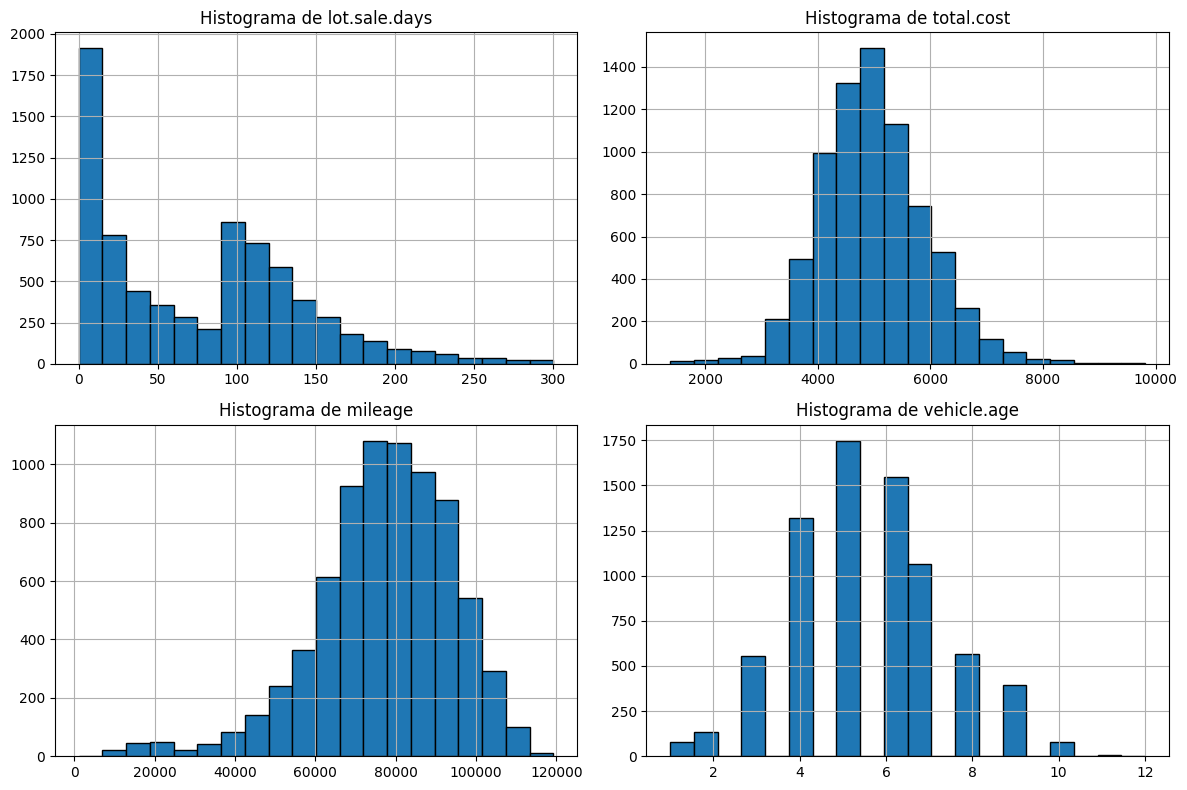

In [50]:
columns = ['lot.sale.days', 'total.cost', 'mileage', 'vehicle.age']

plt.figure(figsize=(12, 8))
for i, col in enumerate(columns, 1):
    plt.subplot(2, 2, i)
    carro[col].hist(bins=20, edgecolor='black')
    plt.title(f"Histograma de {col}")
plt.tight_layout()
plt.show()

**Conclusões**  
* lot.sale.day: Pelo gráfico, nota-se que a maioria dos carros são vendidos nos primeiros 90 dias do ano;
* total.age: A maioria dos carros vendidos estão na faixa de preço de 4 mil e 6 mil;
* mileage: A maioria dos carros vendidos possuem quilometragem entre 60000 e 1000000;
* vehicle.age: Os veículos vendidos tinham majoritariamente entre 4 e 6 anos de idade.

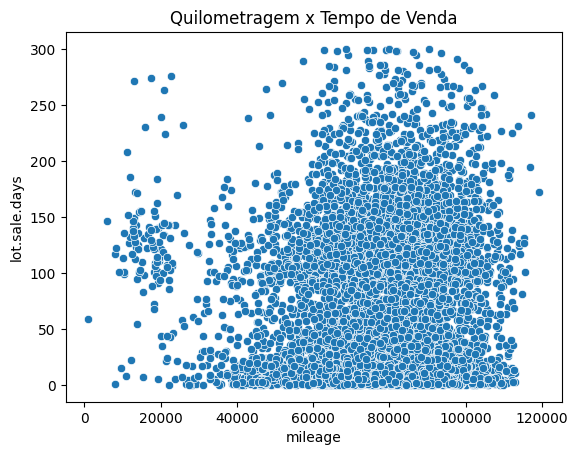

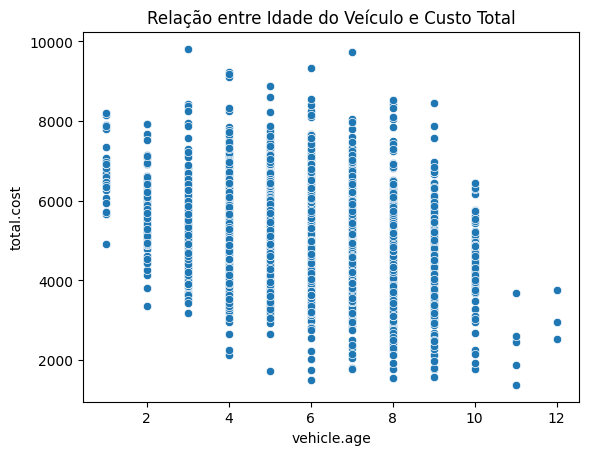

In [51]:
# Gráfico de dispersão
sns.scatterplot(x='mileage', y='lot.sale.days', data=carro)
plt.title('Quilometragem x Tempo de Venda')
plt.show()

sns.scatterplot(x='vehicle.age', y='total.cost', data=carro)
plt.title('Relação entre Idade do Veículo e Custo Total')
plt.show()

In [52]:
carro.groupby('vehicle.type')['lot.sale.days'].mean().sort_values()


vehicle.type
LUXURY           61.976459
FAMILY.SMALL     73.287356
FAMILY.LARGE     74.015385
FAMILY.MEDIUM    80.699403
ECONOMY          85.266598
Name: lot.sale.days, dtype: float64

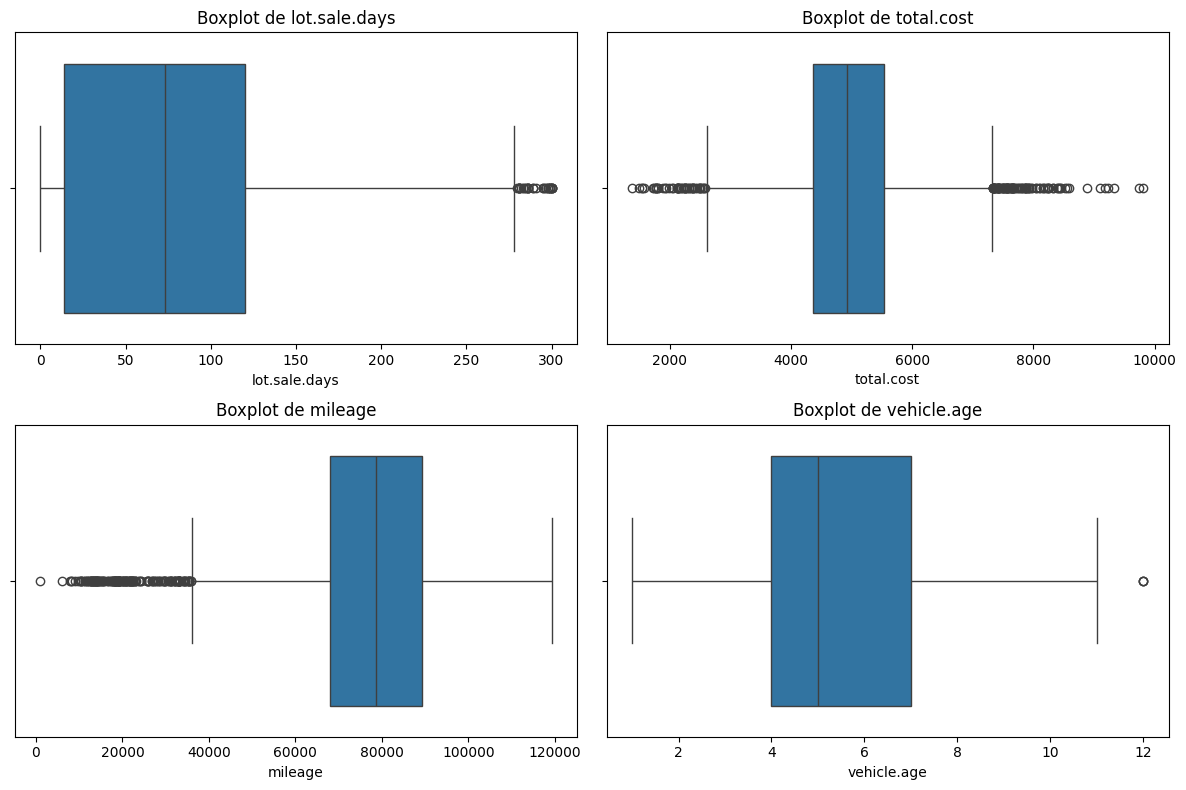

In [53]:
columns = ['lot.sale.days', 'total.cost', 'mileage', 'vehicle.age']
plt.figure(figsize=(12, 8))
for i, col in enumerate(columns, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=carro[col])
    plt.title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()

***7. Resumo estatístico das variáveis numéricas***

In [54]:
carro.describe()

,total.cost,lot.sale.days,mileage,vehicle.age
count,7495.000000,7495.000000,7495.000000,7495.000000
mean,4980.035490,76.454303,77234.533422,5.567312
std,937.602064,64.644337,17142.552588,1.756219
min,1375.000000,0.000000,1036.000000,1.000000
25%,4354.000000,14.000000,67946.000000,4.000000
50%,4919.000000,73.000000,78534.000000,5.000000
75%,5540.000000,120.000000,89340.000000,7.000000
max,9813.000000,300.000000,119250.000000,12.000000


**8. Outlier**

In [55]:
columns = ['lot.sale.days', 'total.cost', 'mileage', 'vehicle.age']
for col in columns:
    # Quartis e IQR
    Q1 = carro[col].quantile(0.25)
    Q3 = carro[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Identificação de outliers
    outliers = carro[(carro[col] < limite_inferior) | (carro[col] > limite_superior)]
    
    # Exibindo resultados
    print(f"Coluna: {col}")
    print(f"  Limite Inferior: {limite_inferior}")
    print(f"  Limite Superior: {limite_superior}")
    print(f"  Número de Outliers: {len(outliers)}")
    print()

Coluna: lot.sale.days
  Limite Inferior: -145.0
  Limite Superior: 279.0
  Número de Outliers: 33

Coluna: total.cost
  Limite Inferior: 2575.0
  Limite Superior: 7319.0
  Número de Outliers: 146

Coluna: mileage
  Limite Inferior: 35855.0
  Limite Superior: 121431.0
  Número de Outliers: 177

Coluna: vehicle.age
  Limite Inferior: -0.5
  Limite Superior: 11.5
  Número de Outliers: 3



### Ajustar o tipo das variáveis  
**Converter variáveis categóricas (strings) para tipo category**

In [56]:
#Para vizualizar variáveis do tipo object/string antes da conversão
carro.select_dtypes(include='category').columns

Index([], dtype='object')

In [57]:
for col in carro.select_dtypes(include='object').columns:
    carro[col] = carro[col].astype('category')

carro.dtypes

ï»¿data.set          category
total.cost              int64
lot.sale.days           int64
overage              category
mileage                 int64
vehicle.type         category
domestic.import      category
vehicle.age             int64
vehicle.age.group    category
color.set            category
makex                category
state                category
make.model           category
dtype: object

### Análise de Correlação

A **Correlação de Pearson** mede a dependência linear entre duas variáveis ​​X e Y. O coeficiente resultante é um valor entre -1 e 1. Onde:  

**a.** 1: Correlação linear positiva perfeita. indicando que quando uma variável aumenta, a outra também aumenta na mesma proporção.  
**b.** 0: Sem correlação linear, as duas variáveis ​​provavelmente não afetam uma à outra.  
**c.** -1: Correlação linear negativa perfeita, indicando que quando uma variável aumenta, a outra diminui na mesma proporção

In [58]:
correlacao = carro.select_dtypes(include=[np.number]).corr(method='pearson')

<Axes: >

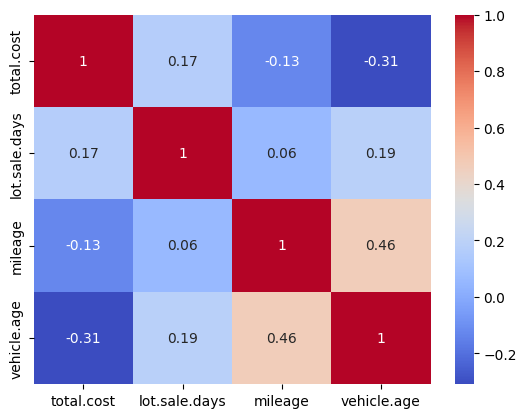

In [59]:
sns.heatmap(correlacao, annot=True, cmap='coolwarm')

**Conclusões**
* Podemos dizer que lot.sale.day (Dias de vendas) tem correlação positiva com total.cost (Custo total) e vehicle.age (Idade do veículo);
* Não existe uma correlação forte entre as variáveis com os dias de vendas (lot.sale.day);
* Há uma correlação negativa entre mileage e vehicle.age com total.cost;

## Parte 2

*1.1. Qual é o tempo médio em dias que os veículos passam no lote antes de serem vendidos (lot.sale.days)?*

In [60]:
print("Tempo médio em dias:", carro['lot.sale.days'].mean().round(2))

Tempo médio em dias: 76.45


*1.2. Veículos de que tipo (vehicle.type) têm o menor tempo de venda?*

In [61]:
veiculo = carro.groupby('vehicle.type', observed=False)['lot.sale.days'].mean().round(2)
print("Veículo com menor tempo de venda:", veiculo.idxmin(), "| Média de dias:", veiculo.min())

Veículo com menor tempo de venda: LUXURY | Média de dias: 61.98


*1.3. Como a quilometragem (mileage) influencia o tempo de venda (lot.sale.days)?*

Correlação de Pearson entre mileage e lot.sale.days: 0.060


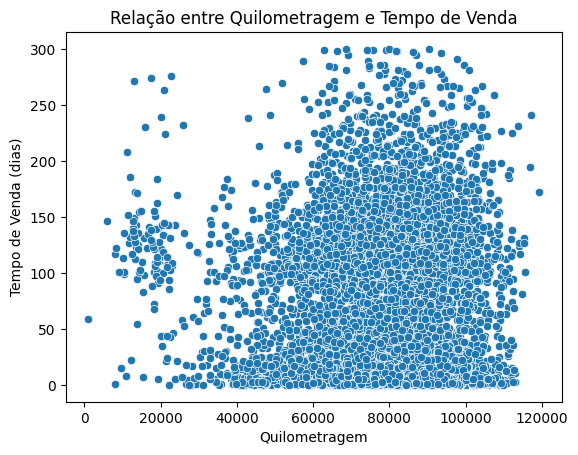

In [62]:
# Correlação entre mileage e lot.sale.days
correlacao_mileage = carro['mileage'].corr(carro['lot.sale.days'])
print(f"Correlação de Pearson entre mileage e lot.sale.days: {correlacao_mileage:.3f}")

# Gráfico de dispersão
sns.scatterplot(x='mileage', y='lot.sale.days', data=carro)
plt.title('Relação entre Quilometragem e Tempo de Venda')
plt.xlabel('Quilometragem')
plt.ylabel('Tempo de Venda (dias)')
plt.show()

**Resposta: Essas duas variáveis possuem uma correlação fraca de apenas 0.060, assim, a quilometragem praticamente não influencia o tempo de venda. Além disso, ao observar o gráfico de disperção sobre a relação mileage e lot.sale.days, nota-se que veículos com maior quilometragem não apresentam de forma consistente tempos de venda maiores ou menores ao ser comparados com os demais**

*1.4. Existe alguma correlação entre o vehicle.age (idade do veículo) e o total.cost (custo total)?*

In [63]:
# Correlação entre o vehicle.age (idade do veículo) e o total.cost (custo total)
correlacao_mileage = carro['vehicle.age'].corr(carro['total.cost'])
print(f"Correlação de Pearson entre vehicle.age e total.cost: {correlacao_mileage:.3f}")


Correlação de Pearson entre vehicle.age e total.cost: -0.310


**Existe uma correlação negativa entre elas (-0.31). Ou seja, quanto maior a idade do veículo, menor é o seu custo total.**

*2.1. Qual é o preço médio dos veículos vendidos, segmentado por state (estado)?*

In [64]:
print("Preço médio dos veículos vendidos por estado:")
carro.groupby('state', observed=False)['total.cost'].mean().round(2)


Preço médio dos veículos vendidos por estado:


state
AZ    4931.40
CA    5064.96
FL    4821.24
GA    5123.23
NM    4691.57
NV    5092.81
TX    5065.81
VA    4881.09
Name: total.cost, dtype: float64

**2.2. Veículos importados (domestic.import) são, em média, mais caros que os domésticos?**

In [65]:
media = carro.groupby('domestic.import', observed=False)['total.cost'].mean().round(2)
if media['Domestic'] > media['Import']:
    print("Veículos domésticos (%.2f) são, em média, mais caros que os importados (%.2f)." % (media['Domestic'], media['Import']))
else:
    print("Veículos importados (%.2f) são, em média, mais caros que os domésticos (%.2f)." % (media['Import'], media['Domestic']))

Veículos importados (5088.14) são, em média, mais caros que os domésticos (4932.47).


**2.3. Existe alguma diferença significativa no total.cost de veículos com cores diferentes (color.set)?**

Resultados do teste de variância (ANOVA):
Estatística F: 9.83
p-valor: 0.0000
Existe diferença significativa no custo total entre pelo menos duas cores.


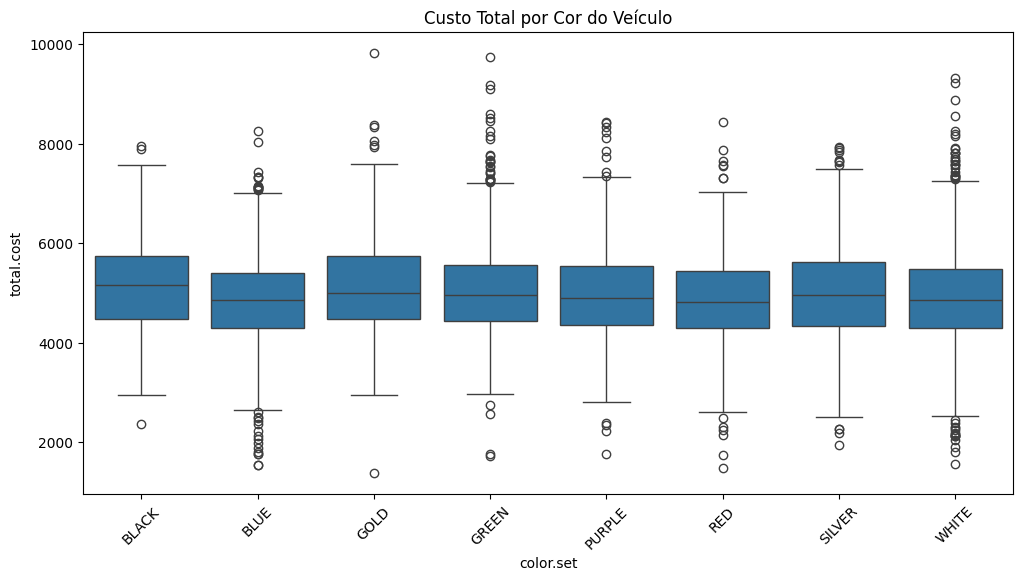

In [66]:
grupos = [grupo['total.cost'].values for _, grupo in carro.groupby('color.set', observed=False)]

# ANOVA (Avalia a variância)
stat, p = f_oneway(*grupos)
print("Resultados do teste de variância (ANOVA):")
print(f"Estatística F: {stat:.2f}")
print(f"p-valor: {p:.4f}")

if p < 0.05:
    print("Existe diferença significativa no custo total entre pelo menos duas cores.")
else:
    print("Não há evidência de diferença significativa no custo total entre as cores.")

# Gráfico de boxplot para visualizar a distribuição do custo total por cor
plt.figure(figsize=(12, 6))
sns.boxplot(x='color.set', y='total.cost', data=carro)
plt.title('Custo Total por Cor do Veículo')
plt.xticks(rotation=45)
plt.show()

**2.4. Como o total.cost varia por vehicle.age.group (grupo de idade) e por tipo de veículo (vehicle.type)?**

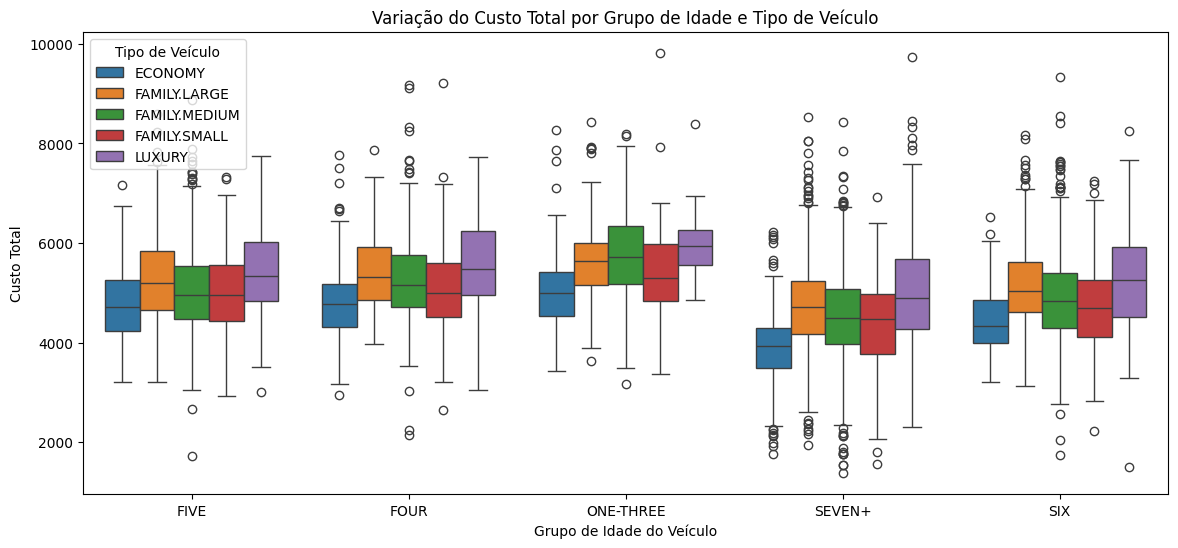

In [ ]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='vehicle.age.group', y='total.cost', hue='vehicle.type', data=carro)
plt.title('Variação do Custo Total por Grupo de Idade e Tipo de Veículo')
plt.xlabel('Grupo de Idade do Veículo')
plt.ylabel('Custo Total')
plt.legend(title='Tipo de Veículo')
plt.show()

*3.1. Quais marcas (makex) e modelos (make.model) são mais vendidas em cada estado?*

In [ ]:
marcas_modelos = carro.groupby(['state', 'makex', 'make.model'], observed=False).size().reset_index(name='count')
marcas_modelos = marcas_modelos.sort_values(by=['state', 'count'], ascending=[True, False])
top_marcas_modelos = marcas_modelos.groupby('state', observed=False).head(1)
print("Marcas e modelos mais vendidos por estado:")
print(top_marcas_modelos[['state', 'makex', 'make.model', 'count']])


Marcas e modelos mais vendidos por estado:
      state      makex         make.model  count
206      AZ  CHEVROLET   CHEVROLET.LUMINA     66
3299     CA     NISSAN      NISSAN.SENTRA    138
5199     FL     NISSAN      NISSAN.SENTRA    103
5906     GA  CHEVROLET   CHEVROLET.LUMINA     68
7805     NM  CHEVROLET  CHEVROLET.CORSICA     11
10504    NV        KIA         KIA.SEPHIA     15
12011    TX       FORD        FORD.TAURUS    111
13911    VA       FORD        FORD.TAURUS     40


**3.2. Quais faixas etárias de veículos (vehicle.age.group) são mais comuns entre os veículos vendidos?**

In [ ]:
print("Faixas etárias de veículos mais comuns entre os vendidos:")
print(carro['vehicle.age.group'].value_counts().sort_values(ascending=False))

Faixas etárias de veículos mais comuns entre os vendidos:
vehicle.age.group
SEVEN+       2115
FIVE         1748
SIX          1544
FOUR         1320
ONE-THREE     768
Name: count, dtype: int64


**4.1. Como a quilometragem (mileage) afeta o total.cost dos veículos, considerando diferentes tipos de veículo (vehicle.type)?**

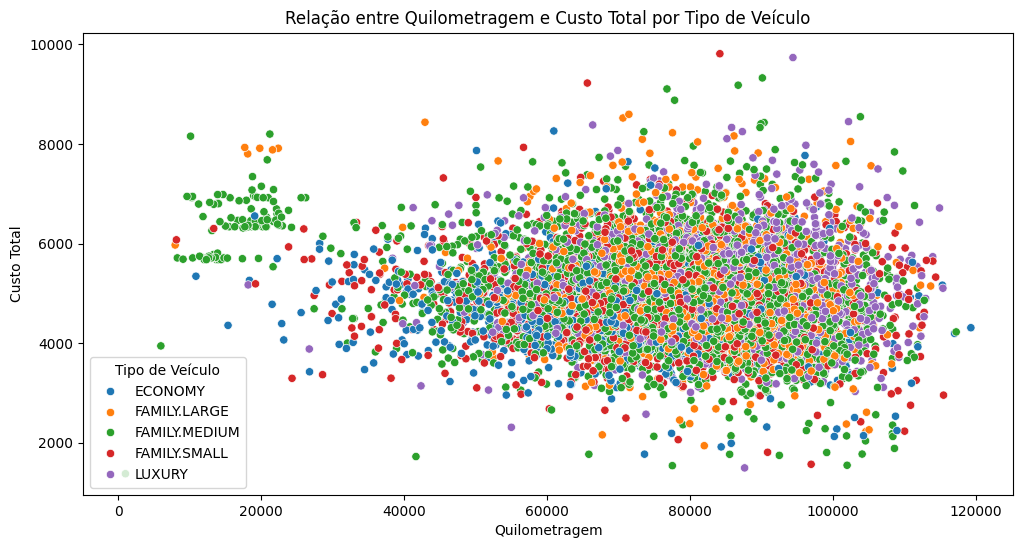

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='mileage', y='total.cost', hue='vehicle.type', data=carro)
plt.title('Relação entre Quilometragem e Custo Total por Tipo de Veículo')
plt.xlabel('Quilometragem')
plt.ylabel('Custo Total')
plt.legend(title='Tipo de Veículo')
plt.show()

* Conclusão: Existe uma leve correlação negativa entre quilometragem e custo total: veículos mais rodados tendem a custar menos.
Essa tendência é consistente entre os diferentes tipos de veículos, embora a magnitude da variação dependa do tipo — veículos do tipo LUXURY tendem a manter preços mais altos mesmo com quilometragem elevada, enquanto ECONOMY e FAMILY.MEDIUM mostram maior queda de valor.

**5.1. Existem veículos que ficaram muito mais tempo no lote do que a média? Quais são suas características?**

In [ ]:
# Calcular a média e o desvio padrão do tempo de venda
media_tempo = carro['lot.sale.days'].mean()
desvio_tempo = carro['lot.sale.days'].std()

# Considerar veículos que ficaram mais de 2 desvios padrão acima da média como "muito mais tempo"
limite_superior = media_tempo + 2 * desvio_tempo

veiculos_muito_tempo = carro[carro['lot.sale.days'] > limite_superior]

print(f"Número de veículos que ficaram muito mais tempo no lote do que a média: {len(veiculos_muito_tempo)}")
veiculos_muito_tempo[['makex', 'make.model', 'state', 'vehicle.type', 'vehicle.age', 'mileage', 'total.cost', 'lot.sale.days']]

Número de veículos que ficaram muito mais tempo no lote do que a média: 279


,makex,make.model,state,vehicle.type,vehicle.age,mileage,total.cost,lot.sale.days
5,CHEVROLET,CHEVROLET.CAVALIER,NM,ECONOMY,7,82771,4370,218
26,PONTIAC,PONTIAC.BONNEVILLE,AZ,FAMILY.LARGE,5,105294,7561,242
37,MAZDA,MAZDA.PROTEGE,GA,ECONOMY,6,74550,5741,283
38,CHEVROLET,CHEVROLET.LUMINA,TX,FAMILY.MEDIUM,3,80435,7959,227
39,BUICK,BUICK.CENTURY,FL,FAMILY.MEDIUM,8,64197,4703,229
...,...,...,...,...,...,...,...,...
3443,OLDSMOBILE,OLDSMOBILE.CIERA,FL,FAMILY.MEDIUM,8,89142,4017,209
3450,MAZDA,MAZDA.PROTEGE,CA,FAMILY.SMALL,7,101969,5667,231
3451,FORD,FORD.TAURUS,VA,FAMILY.MEDIUM,6,74000,6109,255
3457,BUICK,BUICK.REGAL,TX,FAMILY.MEDIUM,7,85517,4771,224


**5.2. Algum estado ou marca apresenta veículos com preços significativamente fora da média?**

In [ ]:
# Média e desvio padrão geral
media_geral = carro['total.cost'].mean()
desvio_geral = carro['total.cost'].std()

# Preço médio por estado
preco_estado = carro.groupby('state', observed=False)['total.cost'].mean()
estados_outlier = preco_estado[(preco_estado > media_geral + 2*desvio_geral) | (preco_estado < media_geral - 2*desvio_geral)]

# Preço médio por marca
preco_marca = carro.groupby('makex', observed=False)['total.cost'].mean()
marcas_outlier = preco_marca[(preco_marca > media_geral + 2*desvio_geral) | (preco_marca < media_geral - 2*desvio_geral)]

print("Estados com preços significativamente fora da média:")
print(estados_outlier)

print("\nMarcas com preços significativamente fora da média:")
print(marcas_outlier)

Estados com preços significativamente fora da média:
Series([], Name: total.cost, dtype: float64)

Marcas com preços significativamente fora da média:
Series([], Name: total.cost, dtype: float64)


**6.1. Qual é a cor mais popular (color.set) entre os veículos vendidos?**

In [ ]:
print("Cor mais popular entre os veículos vendidos:")
print(carro['color.set'].value_counts().sort_values(ascending=False).head(1))

Cor mais popular entre os veículos vendidos:
color.set
WHITE    1602
Name: count, dtype: int64


**6.2. Veículos de quais marcas ou modelos têm melhor desempenho em cada estado?**

In [ ]:
# Calcular o tempo médio de venda por estado, marca e modelo
desempenho = carro.groupby(['state', 'makex', 'make.model'], observed=True)['lot.sale.days'].mean().reset_index()

# Para cada estado, selecionar a marca/modelo com menor tempo médio de venda
melhor_desempenho = desempenho.loc[desempenho.groupby('state', observed=True)['lot.sale.days'].idxmin()]

print("Marcas e modelos com melhor desempenho (menor tempo de venda) por estado:")
print(melhor_desempenho.sort_values(by='state')[['state', 'makex', 'make.model', 'lot.sale.days']])


Marcas e modelos com melhor desempenho (menor tempo de venda) por estado:
    state       makex              make.model  lot.sale.days
59     AZ  OLDSMOBILE     OLDSMOBILE.INTRIGUE            4.0
82     CA    CADILLAC        CADILLAC.SEVILLE            0.0
157    FL    CADILLAC  CADILLAC.FLEETWOOD RWD            4.5
266    GA      NISSAN           NISSAN.MAXIMA            0.0
333    NM       OTHER           SUZUKI.ESTEEM            1.0
349    NV       BUICK        BUICK.ROADMASTER            7.0
450    TX  OLDSMOBILE        OLDSMOBILE.ALERO            3.0
533    VA       OTHER            EAGLE.VISION            0.0
